# Assignment 2: Image Classification Using CNN



## Import the required libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import Sequential
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

np.random.seed(42)
tf.random.set_seed(42)

## Part 1 - Data Preparation



In [2]:
# Load the Fashion-MNIST dataset.
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

class_names = [
    "T-shirt / Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot",
]

print("Number of training images:", X_train.shape[0])
print("Number of testing images:", X_test.shape[0])
print("Image dimensions:", X_train.shape[1:])

Number of training images: 60000
Number of testing images: 10000
Image dimensions: (28, 28)


In [3]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Training data shape after reshaping:", X_train.shape)
print("Testing data shape after reshaping:", X_test.shape)
print("Minimum normalized pixel value:", X_train.min())
print("Maximum normalized pixel value:", X_train.max())

Training data shape after reshaping: (60000, 28, 28, 1)
Testing data shape after reshaping: (10000, 28, 28, 1)
Minimum normalized pixel value: 0.0
Maximum normalized pixel value: 1.0


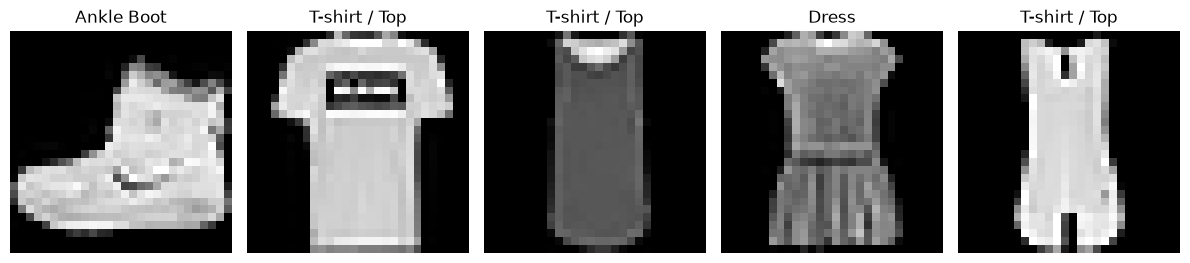

In [4]:
# Display five training images with their class labels.
plt.figure(figsize=(12, 3))

for index in range(5):
    plt.subplot(1, 5, index + 1)
    plt.imshow(X_train[index].squeeze(), cmap="gray")
    plt.title(class_names[y_train[index]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Part 2 - Building the CNN Model



In [5]:
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, kernel_size=(3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax"),
])

# Adam adjusts the model weights during training.
# Sparse categorical crossentropy is used because labels are integers 0-9.
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Part 3 - Model Training



In [6]:
EPOCHS = 10
BATCH_SIZE = 32

history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.10,
    verbose=1,
)

final_training_accuracy = history.history["accuracy"][-1]
print(f"\nNumber of epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Final training accuracy: {final_training_accuracy:.2%}")

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8339 - loss: 0.4576 - val_accuracy: 0.8747 - val_loss: 0.3445
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8883 - loss: 0.3079 - val_accuracy: 0.8897 - val_loss: 0.3024
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9043 - loss: 0.2603 - val_accuracy: 0.8912 - val_loss: 0.3003
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9173 - loss: 0.2244 - val_accuracy: 0.8957 - val_loss: 0.2922
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9286 - loss: 0.1943 - val_accuracy: 0.8968 - val_loss: 0.3053
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9382 - loss: 0.1692 - val_accuracy: 0.8955 - val_loss: 0.3202
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9462 - loss: 0.1475 - val_accuracy: 0.9018 - val_loss: 0.3133
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9539 - loss: 0.1266

## Part 4 - Model Evaluation

In [7]:
# Evaluate the model using images that were not used for training.
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Test loss: 0.3750
Test accuracy: 90.22%


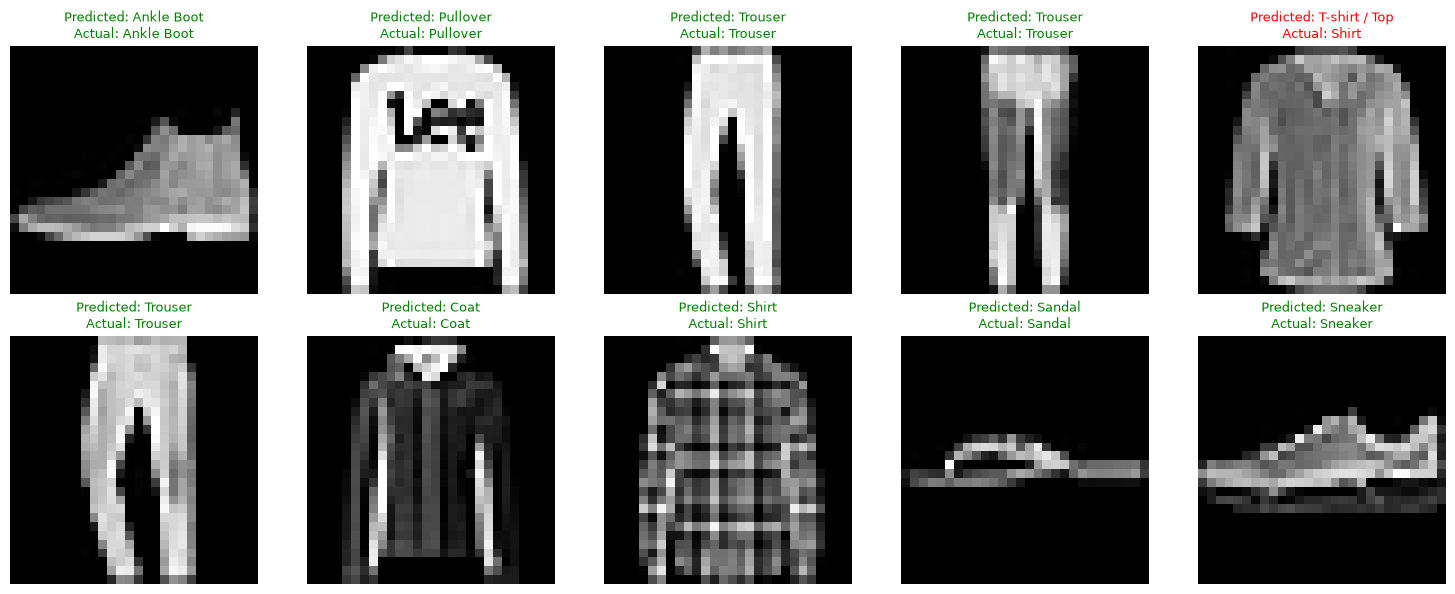

In [8]:
# model.predict returns 10 probabilities for every test image.
prediction_probabilities = model.predict(X_test, verbose=0)
predicted_labels = np.argmax(prediction_probabilities, axis=1)

plt.figure(figsize=(15, 6))

for index in range(10):
    plt.subplot(2, 5, index + 1)
    plt.imshow(X_test[index].squeeze(), cmap="gray")
    predicted_name = class_names[predicted_labels[index]]
    actual_name = class_names[y_test[index]]
    title_color = "green" if predicted_labels[index] == y_test[index] else "red"
    plt.title(
        f"Predicted: {predicted_name}\nActual: {actual_name}",
        color=title_color,
        fontsize=9,
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

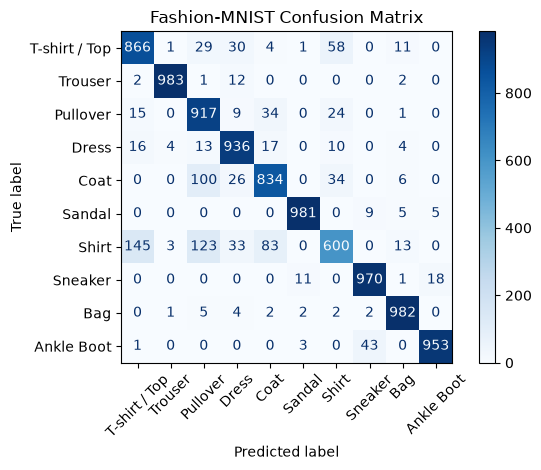

In [9]:
# Confusion matrix: rows are actual classes and columns are predictions.
matrix = confusion_matrix(y_test, predicted_labels, labels=range(10))

display = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=class_names,
)
display.plot(cmap="Blues", xticks_rotation=45, values_format="d")
plt.title("Fashion-MNIST Confusion Matrix")
plt.tight_layout()
plt.show()

In [10]:
# The classification report shows precision, recall, and F1-score.
report = classification_report(
    y_test,
    predicted_labels,
    labels=range(10),
    target_names=class_names,
)
print("Classification Report:\n")
print(report)

Classification Report:

               precision    recall  f1-score   support

T-shirt / Top       0.83      0.87      0.85      1000
      Trouser       0.99      0.98      0.99      1000
     Pullover       0.77      0.92      0.84      1000
        Dress       0.89      0.94      0.91      1000
         Coat       0.86      0.83      0.84      1000
       Sandal       0.98      0.98      0.98      1000
        Shirt       0.82      0.60      0.69      1000
      Sneaker       0.95      0.97      0.96      1000
          Bag       0.96      0.98      0.97      1000
   Ankle Boot       0.98      0.95      0.96      1000

     accuracy                           0.90     10000
    macro avg       0.90      0.90      0.90     10000
 weighted avg       0.90      0.90      0.90     10000



## Part 5 - Model Analysis

### 1. Why are CNNs more suitable than ANNs for image classification?
CNNs preserve the spatial relationship between nearby pixels. They can learn useful image features such as edges, shapes, and textures. A basic ANN usually flattens the image immediately, which loses much of this spatial information and often requires many more parameters.

### 2. What is the purpose of a convolution layer?
A convolution layer moves small filters across an image. During training, these filters learn to detect useful patterns. Early layers may find edges, while later layers may find more complex shapes.

### 3. Why is max pooling used in CNNs?
Max pooling keeps the strongest value from each small area of a feature map. This reduces its width and height, lowers the amount of computation, and keeps the most important detected features.

### 4. Why is the Flatten layer required before the Dense layers?
Convolution and pooling layers produce 2D feature maps. A dense layer expects a 1D list of values. Flatten converts the feature maps into that list without changing their values.

### 5. Why is Softmax used in the output layer?
Softmax converts the 10 output values into probabilities that add up to 1. The class with the highest probability becomes the model's prediction.

### 6. How does the Adam optimizer help in training the CNN?
Adam updates the model's weights to reduce prediction error. It automatically adjusts the learning step for each weight by using information from recent gradients. This usually helps the model learn efficiently with little manual tuning.